In [215]:
import torch
import matplotlib.pyplot as plt

In [216]:
def generateData(num_samples = 100):
    torch.manual_seed(42)
    x = torch.empty(num_samples).uniform_(0, 1000)
    f_x = 3 * x + 2
    eps = torch.randn(num_samples)
    y = f_x + eps
    return x, y

In [217]:
def gradient(X, y, theta): return (1/len(y)) * X.T @ (X @ theta - y)
def loss(X, y, theta): return torch.mean((X @ theta - y)**2) / 2

def show_graph(losses):
    plt.figure(figsize=(10, 6))
    plt.plot(torch.arange(1, len(losses) + 1), losses)
    plt.title('MSE Loss vs. Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Mean Squared Error (MSE) Loss')
    plt.xscale('log') # Use a log scale for the x-axis to better visualize the long tail
    plt.grid(True)
    plt.show()

def gd(X, y, learning_rate = 0.01, epsilon=0.001, max_iterations=50000):
    theta_star = torch.inverse(X.T@X)@X.T@y
    theta = torch.zeros((X.shape[1], 1))
    
    losses = []
    for _ in range(max_iterations):
        theta = theta - learning_rate*gradient(X, y, theta)
        losses.append(loss(X, y, theta))
        if torch.norm(theta - theta_star) < epsilon:
            print(f"Algorithm converged in {len(losses)} iterations")
            break
    else:
        print(f"Algorithm did not converge even in {max_iterations} iterations")

    return theta, theta_star, losses

Algorithm did not converge even in 50000 iterations
Gradient Descent parameters -  tensor([[3.0026],
        [0.1362]])
Normal Equation parameters -  tensor([[2.9995],
        [2.2312]])


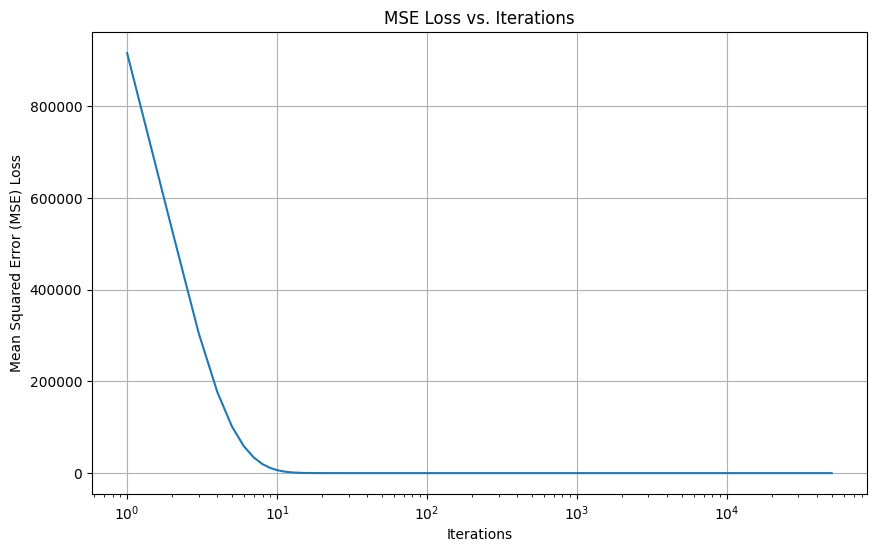

In [218]:
# Without Normalization
X, y = generateData()
X = torch.vstack((X, torch.ones(X.shape[0]))).T
y = torch.reshape(y, (len(y), 1)) # Correct the dimensions
theta, theta_star, losses = gd(X, y, 0.000005)
print("Gradient Descent parameters - ", theta)
print("Normal Equation parameters - ", theta_star)
show_graph(losses)

Algorithm converged in 137 iterations
Gradient Descent parameters -  tensor([[ 883.5209],
        [1549.4811]])
Normal Equation parameters -  tensor([[ 883.5215],
        [1549.4818]])


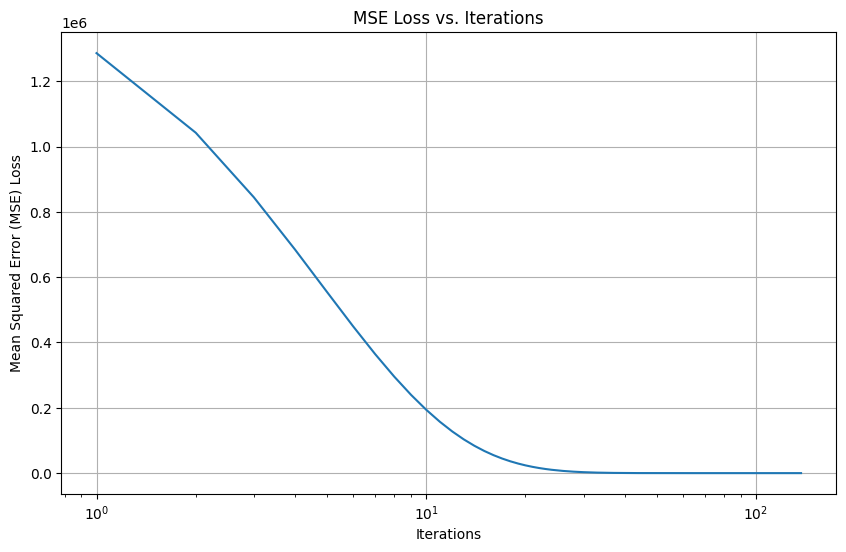

In [219]:
# With z normalization
torch.manual_seed(42)
X, y = generateData()
y = torch.reshape(y, (len(y), 1)) # Correct the dimensions from (N,) to (N, 1)
mean = X.mean(dim=0)
std = X.std(dim=0)
X = (X - mean) / std # Z normalization
X = torch.vstack((X, torch.ones(X.shape[0]))).T # Add bias term
theta, theta_star, losses = gd(X, y, 0.1)
print("Gradient Descent parameters - ", theta)
print("Normal Equation parameters - ", theta_star)
show_graph(losses)

# Observations

The performance of gradient descent is highly sensitive to the scale of input features. When features have vastly different scales, like an input x ranging from 0-1000 versus a constant bias term of 1, the loss landscape becomes a distorted, narrow canyon. In this scenario, a high learning rate causes the algorithm to diverge as its updates overshoot the minimum entirely. To prevent this, a tiny learning rate is required, but this leads to extremely slow convergence (hundreds of thousands of iterations) as the algorithm takes minuscule, zig-zagging steps down the canyon.

Applying Z-score normalization is the solution to this problem. Scaling transforms the difficult "canyon" into a symmetrical, round "bowl" where all features have a similar scale. This allows the gradient to point more directly toward the minimum, making the optimization process highly efficient. As a result, a much larger learning rate can be used, allowing the algorithm to converge in fewer than 100 iterations. This demonstrates that feature scaling is a critical preprocessing step for making gradient-based algorithms fast and effective.